In [101]:
import pandas as pd
import numpy as np
import pandas.io.sql as sqlio
import psycopg2 as ps
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE




In [102]:
conn = ps.connect(
    dbname='tech4',
    user='postgres',
    password='Pfi@213zer',
    host='localhost',
    port='5433')

In [103]:
sql = """
SELECT *
FROM analytics.obesity_base
"""


In [104]:
df = sqlio.read_sql_query(sql, conn)

C:\Users\excel\AppData\Local\Temp\ipykernel_31856\76855033.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = sqlio.read_sql_query(sql, conn)


In [105]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Pipeline em ML

In [106]:
df['obesity_target'] = df['Obesity'].apply(
    lambda x: 1 if x.startswith('Obesity') else 0
)

In [107]:
binary_cols = ['family_history', 'FAVC', 'SMOKE', 'SCC']

In [108]:
df[binary_cols] = df[binary_cols].apply(
    lambda x: x.str.lower().str.strip()
)


In [109]:
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


C:\Users\excel\AppData\Local\Temp\ipykernel_31856\2505204152.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


In [110]:
df[binary_cols].info()
df[binary_cols].head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   family_history  2111 non-null   int64
 1   FAVC            2111 non-null   int64
 2   SMOKE           2111 non-null   int64
 3   SCC             2111 non-null   int64
dtypes: int64(4)
memory usage: 66.1 KB


,family_history,FAVC,SMOKE,SCC
0,1,0,0,0
1,1,0,1,1
2,1,0,0,0
3,0,0,0,0
4,0,0,0,0


In [111]:
df.drop(['Weight'], axis=1, inplace=True)

In [112]:
X = df.drop(columns=['obesity_target'])
y = df['obesity_target']


In [113]:
# Colunas numéricas
num_features = [
    'Height', 'Age', 'FCVC', 'NCP',
    'CH2O', 'FAF', 'TUE'
]

# Colunas categóricas
cat_features = [
    'Gender', 'family_history', 'FAVC',
    'CAEC', 'SMOKE', 'SCC',
    'CALC', 'MTRANS'
]


In [114]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)


In [115]:
modelo = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear'
)


In [116]:
pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', modelo)
    ]
)


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


In [118]:
pipeline.fit(X_train, y_train)


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The giv

In [119]:
y_prob = pipeline.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)

print(f"AUC: {auc:.3f}")


AUC: 0.843


In [120]:
threshold = 0.55
y_pred = (y_prob >= threshold).astype(int)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (threshold={threshold}): {acc:.3f}")


Accuracy (threshold=0.55): 0.767


In [121]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.65      0.75       285
           1       0.69      0.90      0.78       243

    accuracy                           0.77       528
   macro avg       0.79      0.78      0.77       528
weighted avg       0.80      0.77      0.76       528



In [122]:
from scipy import stats

ks = stats.ks_2samp(
    y_prob[y_test == 0],
    y_prob[y_test == 1]
)

print(f"KS Statistic: {ks.statistic:.3f}")
print(f"P-value: {ks.pvalue:.5f}")


KS Statistic: 0.557
P-value: 0.00000


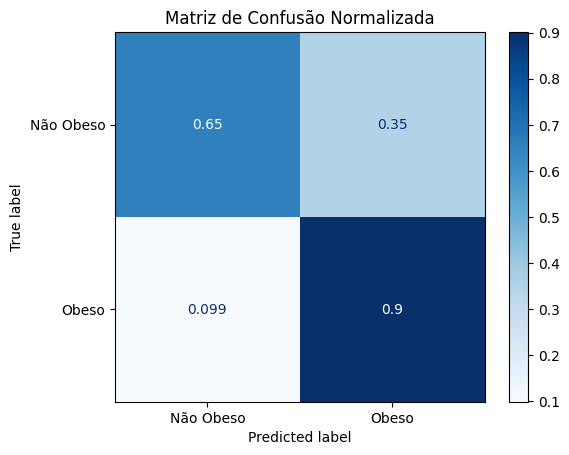

In [123]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize='true',
    display_labels=['Não Obeso', 'Obeso'],
    cmap=plt.cm.Blues
)

plt.title("Matriz de Confusão Normalizada")
plt.grid(False)
plt.show()


In [124]:
from sklearn.linear_model import LogisticRegression

pipe_log = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_log.fit(X_train, y_train)

y_prob_log = pipe_log.predict_proba(X_test)[:, 1]
y_pred_log = (y_prob_log >= 0.55).astype(int)


In [125]:
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.89      0.66      0.75       285
           1       0.69      0.90      0.78       243

    accuracy                           0.77       528
   macro avg       0.79      0.78      0.77       528
weighted avg       0.80      0.77      0.77       528



In [126]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

pipe_xgb.fit(X_train, y_train)

y_prob_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.55).astype(int)


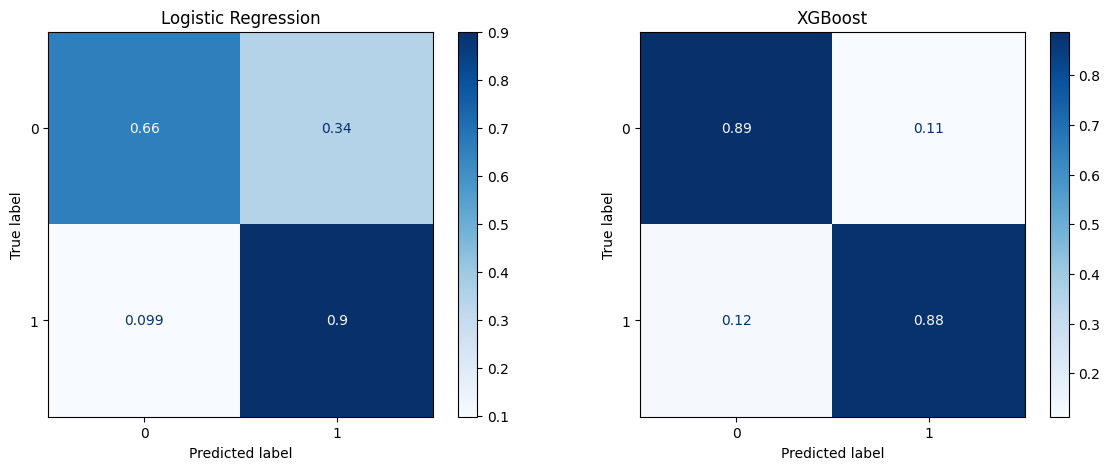

In [127]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    normalize='true',
    ax=ax[0],
    cmap=plt.cm.Blues
)
ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    normalize='true',
    ax=ax[1],
    cmap=plt.cm.Blues
)
ax[1].set_title("XGBoost")

plt.show()


In [128]:
ks_log = stats.ks_2samp(
    y_prob_log[y_test == 0],
    y_prob_log[y_test == 1]
)

ks_xgb = stats.ks_2samp(
    y_prob_xgb[y_test == 0],
    y_prob_xgb[y_test == 1]
)

print(f"KS Logistic: {ks_log.statistic:.3f}")
print(f"KS XGBoost: {ks_xgb.statistic:.3f}")


KS Logistic: 0.557
KS XGBoost: 0.790


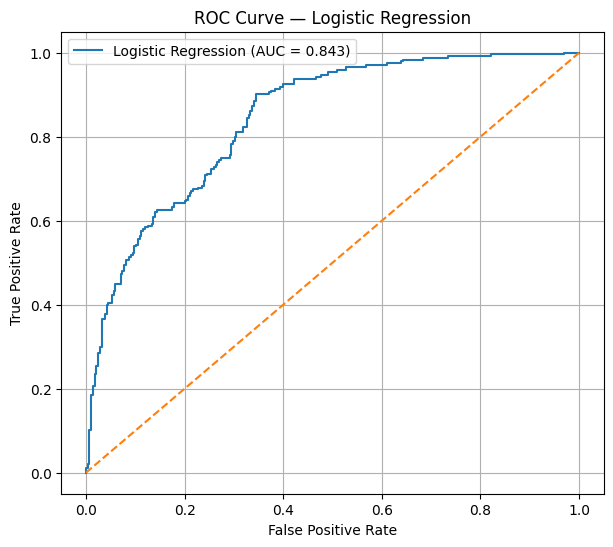

In [129]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilidades
y_prob_log = pipe_log.predict_proba(X_test)[:, 1]

# Curva ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()


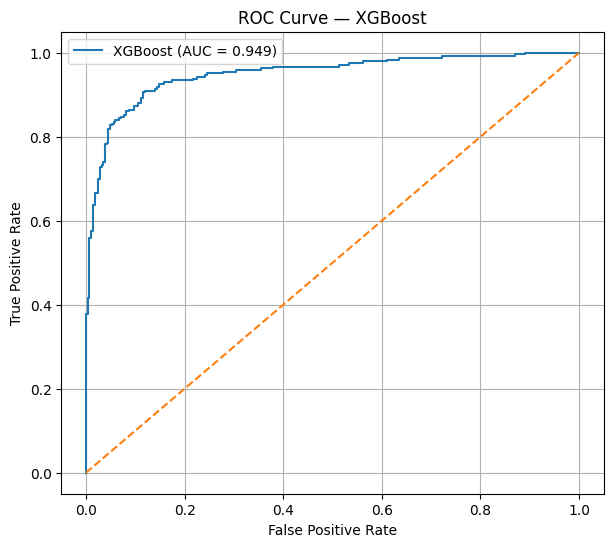

In [130]:
# Probabilidades
y_prob_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

# Curva ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost')
plt.legend()
plt.grid(True)
plt.show()


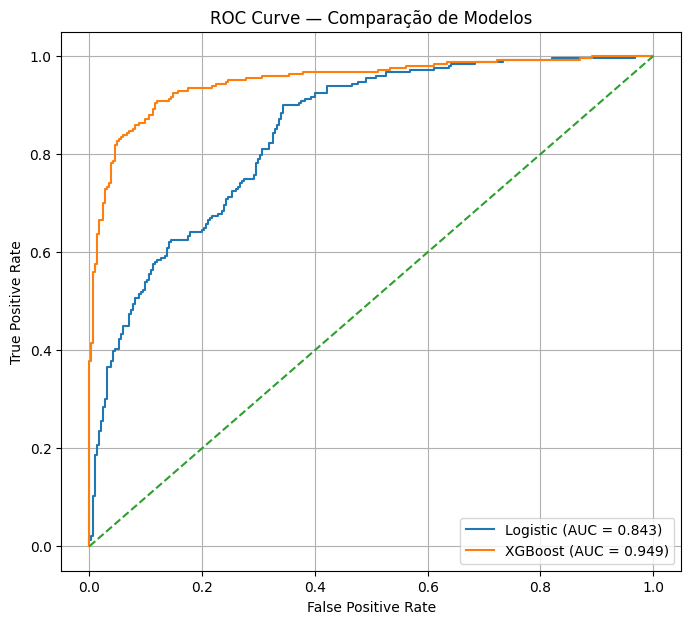

In [131]:
plt.figure(figsize=(8, 7))

plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC = {auc_log:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Comparação de Modelos')
plt.legend()
plt.grid(True)
plt.show()


In [132]:
y_prob_xgb = pipe_xgb.predict_proba(X_test)[:, 1]


In [133]:
threshold = 0.55
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)


In [134]:
from sklearn.metrics import classification_report

print("\nClassification Report — XGBoost\n")
print(classification_report(y_test, y_pred_xgb))



Classification Report — XGBoost

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       285
           1       0.87      0.88      0.88       243

    accuracy                           0.88       528
   macro avg       0.88      0.88      0.88       528
weighted avg       0.88      0.88      0.88       528



In [135]:
print("LOGISTIC REGRESSION\n")
print(classification_report(y_test, y_pred))

print("\nXGBOOST\n")
print(classification_report(y_test, y_pred_xgb))


LOGISTIC REGRESSION

              precision    recall  f1-score   support

           0       0.89      0.65      0.75       285
           1       0.69      0.90      0.78       243

    accuracy                           0.77       528
   macro avg       0.79      0.78      0.77       528
weighted avg       0.80      0.77      0.76       528


XGBOOST

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       285
           1       0.87      0.88      0.88       243

    accuracy                           0.88       528
   macro avg       0.88      0.88      0.88       528
weighted avg       0.88      0.88      0.88       528



In [136]:
import joblib

joblib.dump(pipe_xgb, "modelo_xgb_obesidade.joblib")


['modelo_xgb_obesidade.joblib']